<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_0_Preliminaries/17_0_2_VisualizingAssociations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression Preliminaries: Visualizing Associations
---



## What This Notebook Is About

In the previous notebook we lived in one dimension. We had a single variable, penguin body mass, and asked *"With no other information, what is our best guess for a new penguin's weight, and how wrong should we expect to be?"* Our answer was the mean (≈4207 g) with a typical error (standard deviation) of about 801 g.

That error is the problem and it is an opportunity to improve our model. To shrink the error, we need another variable to lean on: something like the penguin's flipper length, or its species. In other words, we need to leave the 1D world and enter the 2D world, where every observation has both an $x$ and a $y$.

In this notebook we'll do three things:

1. Introduce the scatterplot. The single most important picture in applied statistics.
2. Warn you about trusting summary statistics alone, via Anscombe's Quartet.
3. Distinguish outliers from high-leverage points; two very different kinds of "weird data."

The big takeaway from this notebook is that you never fit a model to data you haven't looked at. Visualizing is key.

## Setup

We'll use two datasets. Both are *famous* in statistics precisely because they exist to prove this notebook's point.

- **Anscombe's Quartet**: Four tiny 2D datasets built in 1973 by statistician F. J. Anscombe.
- **The Datasaurus Dozen**: A modern 2017 follow-up with thirteen datasets (including a literal dinosaur).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import io
import urllib.request

sns.set_style('whitegrid')

# Anscombe's Quartet ships with seaborn.
anscombe = sns.load_dataset('anscombe')
print('Anscombe shape:', anscombe.shape)
anscombe.head()

Anscombe shape: (44, 3)


,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


---

## Section 1: From 1D to 2D — The Scatterplot

### The Scenario

Last time we had to guess a penguin's weight knowing *nothing* about it the individual penguin. We only knew the average penguin weight and the deviance.

Now imagine the deal changes: before guessing the weight, we get to measure the penguin's **flipper length**. Do we think flipper length will help? Intuitively, yes. Bigger flippers tend to belong to bigger penguins. But to see whether two variables move together, we need a new kind of picture.

### The Scatterplot

A scatterplot is a simple idea: each row in your data becomes one dot on a 2D plane. The dot's horizontal position comes from one variable ($x$) and its vertical position comes from another variable ($y$).

Let's look at Dataset I from Anscombe's Quartet.

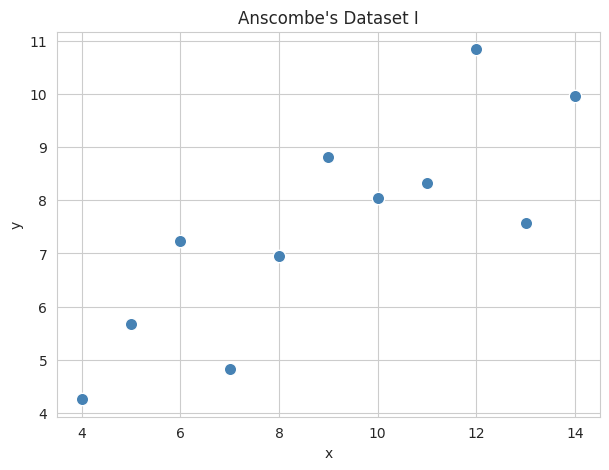

In [ ]:
ds1 = anscombe[anscombe['dataset'] == 'I']

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ds1['x'], ds1['y'], s=80, color='steelblue', edgecolor='white')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title("Anscombe's Dataset I")
plt.show()

**Reading this picture:** each dot is a single observation with two attributes ($x$ and $y$). Look at the overall shape: as $x$ increases, $y$ tends to increase too. The cloud of points drifts upward from left to right. There's a **relationship** here.

If someone asked you *"If x=13, what do you expect y to be?"*, you'd have a meaningful answer, even without any math yet. You can mentally draw a line through those points.

That's the power of the scatterplot: it lets you see whether $x$ carries information about $y$. Which is exactly what regression is going to build on.

---

## Section 2: Anscombe's Trap

### The Illusion of Math

Data scientists love numbers. It's tempting to skip the scatterplot entirely. It feels slow, imprecise, unscientific. We could instead  just ask the computer for summary statistics. After all, the computer can crunch means and variances instantly on a million-row dataset. Why bother squinting at dots?

Anscombe's Quartet contains **four** datasets. Let's compute the mean of $x$, mean of $y$, variance of $x$, and variance of $y$ for each one, and compare them.

In [ ]:
summary = anscombe.groupby('dataset').agg(
    mean_x=('x', 'mean'),
    mean_y=('y', 'mean'),
    var_x =('x', 'var'),
    var_y =('y', 'var'),
).round(2)
summary

,mean_x,mean_y,var_x,var_y
dataset,,,,
I,9.0,7.5,11.0,4.13
II,9.0,7.5,11.0,4.13
III,9.0,7.5,11.0,4.12
IV,9.0,7.5,11.0,4.12


### The Trap

Look closely at that table. All four datasets have (to two decimal places):

- mean of $x$ = **9.00**
- mean of $y$ ≈ **7.50**
- variance of $x$ = **11.00**
- variance of $y$ ≈ **4.13**

**The four datasets are statistical twins.** If you handed these summary numbers to a colleague and asked *"Describe these datasets to me,"* they would have no way to tell them apart. They would probably assume the datasets look essentially the same.

Before you scroll: take a moment to predict. If I plot all four datasets side-by-side, what will the scatterplots look like?

Now let's reveal the truth.

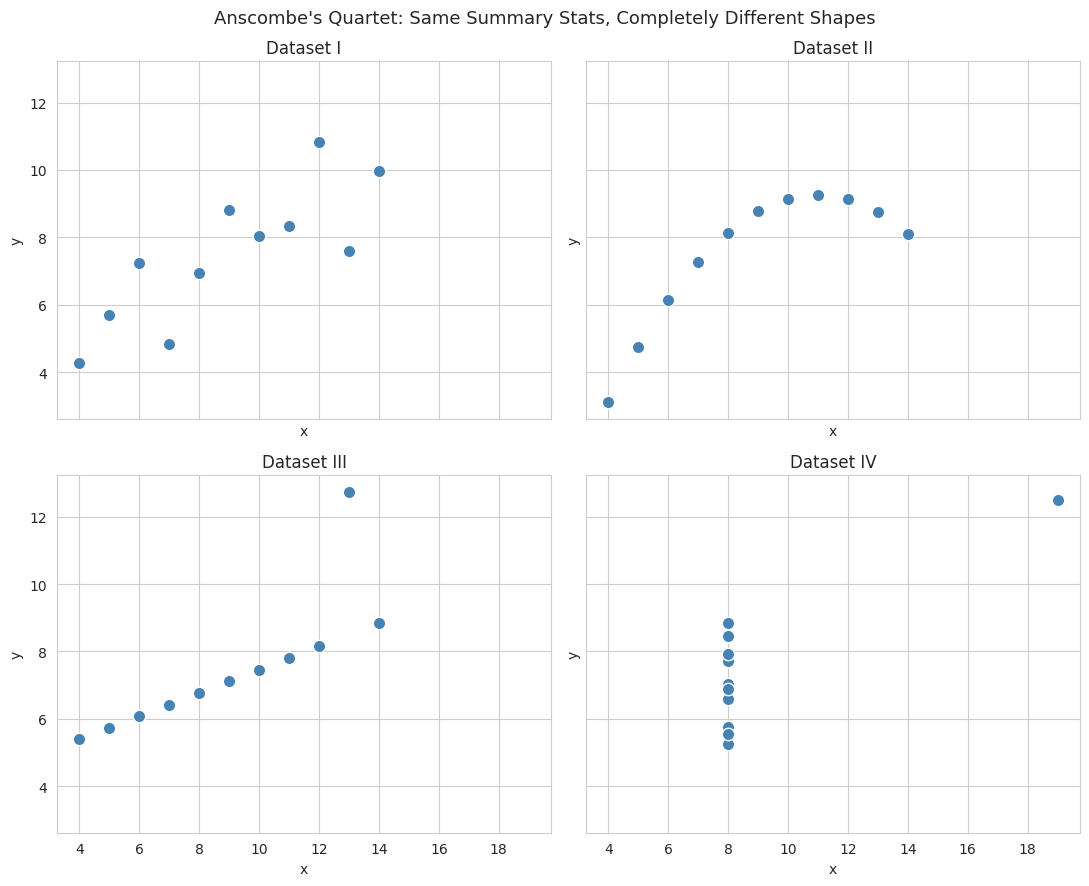

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)

for ax, label in zip(axes.flat, ['I', 'II', 'III', 'IV']):
    subset = anscombe[anscombe['dataset'] == label]
    ax.scatter(subset['x'], subset['y'], s=80, color='steelblue', edgecolor='white')
    ax.set_title(f"Dataset {label}")
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.suptitle("Anscombe's Quartet: Same Summary Stats, Completely Different Shapes",
             fontsize=13)
plt.tight_layout()
plt.show()

Walk through them one at a time:

- **Dataset I**: A noisy but honest linear relationship. This is the kind of thing regression is made for.
- **Dataset II**: A perfect curve (a parabola). There is a clean relationship, but it is not linear. A straight-line model will miss the pattern entirely.
- **Dataset III**: A perfect straight line... except for one point way up top. That single point is going to distort any line we try to fit.
- **Dataset IV**: Almost all the $x$ values are identical. The relationship we "see" is entirely manufactured by a single point way off to the right.

### The Lesson

Summary statistics are mathematically blind to geometry. Means and variances describe marginal distributions, that is, how each variable is spread out on its own, but they cannot see the shape of the relationship.

This is not a curiosity. It is the central warning of this notebook:

> **If you fit a linear regression to Dataset II without looking at it, the math will happily produce an answer. It will have a slope, an intercept, and an $R^2$. And it will be meaningless, because the underlying relationship isn't a line.**

Datasets III and IV fail in two other interesting ways; ways that foreshadow two different kinds of trouble.

---

## Section 3: Outliers vs. High-Leverage Points

Datasets III and IV both contain a *single* unusual point. But those two unusual points do fundamentally different damage to any models we try to develop. We need vocabulary to tell them apart.

- An **outlier** is a point whose $y$-value doesn't fit the pattern the rest of the data suggests.
- A **high-leverage point** is a point whose $x$-value is far from the rest of the $x$'s.

Those are very different things. Let's see why.

### Outlier: Dataset III

In Dataset III, ten of the points lie on a perfect straight line. The eleventh point sits up high, away from that line. Its $x$-value is **near the middle** of the range, but its $y$-value breaks the pattern.

Let's add a line of best fit and see what it does.

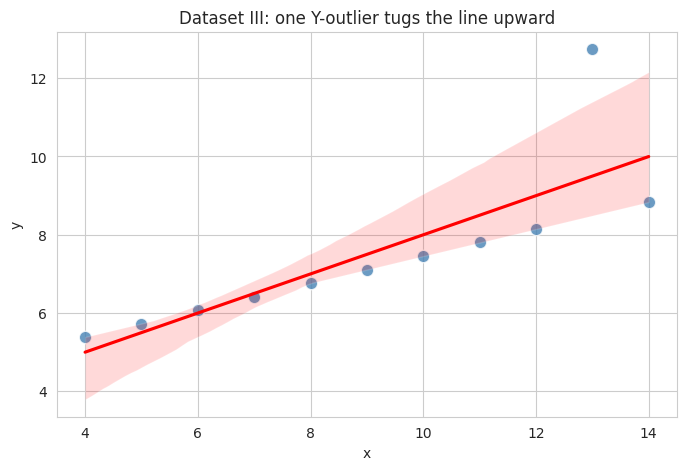

In [ ]:
ds3 = anscombe[anscombe['dataset'] == 'III']

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=ds3, x='x', y='y', ax=ax,
            scatter_kws={'s': 80, 'color': 'steelblue', 'edgecolor': 'white'},
            line_kws={'color': 'red'})
ax.set_title("Dataset III: One Y-outlier tugs the line upward")
plt.show()

Notice what happened:

- The underlying relationship really is linear, ten of the eleven points lie on a line.
- The rogue point is an outlier in the y-direction. It doesn't fit the pattern.
- The line of best fit is pulled upward a bit, trying to partially accommodate the outlier.
- But because the outlier's $x$ is in the middle of the pack, its pulling power is limited. It ruins our accuracy (the line no longer hits the true pattern exactly) but it doesn't destroy the trend. The overall upward slope is still there.

A y-outlier makes your model a bit worse. Survivable.

### High Leverage: Dataset IV

Dataset IV is different. Ten of the eleven points have the exact same $x$-value (x = 8). They are stacked vertically on top of each other. If you only looked at those ten points, you would conclude that $x$ tells you nothing about $y$; The $y$'s just vary around some average, and $x$ is constant.

But then there's one rogue point way over at $x = 19$, far from the rest of the $x$'s. Watch what the line of best fit does.

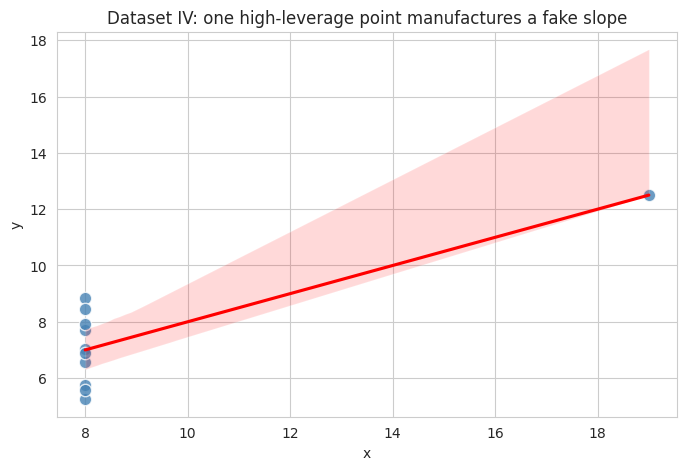

In [ ]:
ds4 = anscombe[anscombe['dataset'] == 'IV']

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=ds4, x='x', y='y', ax=ax,
            scatter_kws={'s': 80, 'color': 'steelblue', 'edgecolor': 'white'},
            line_kws={'color': 'red'})
ax.set_title("Dataset IV: One high-leverage point manufactures a fake slope")
plt.show()

The regression line has a clean, confident upward slope, as if $x$ strongly predicts $y$. But that slope is a lie. It is being generated, single-handedly, by the one point off on the right.

Why does a single point have such enormous power?

### Leverage: The physics analogy

Think of the regression line as a physical lever, and each data point as a hand pressing on it. A point far from the center of the $x$-values has a long moment arm. It can generate huge torque with a tiny force. A point near the center has a short moment arm. Even pressing hard, it can barely tilt the line.

In statistics, we call this **leverage**. A point with an extreme $x$-value is a high-leverage point. It has disproportionate power over the fitted line.

When a high-leverage point also happens to land in a weird spot (like our Dataset IV outlier), a *single observation* can completely dictate the slope, and completely fabricate a relationship that isn't really there.

### The core principle

> **Y-outliers hurt your model's accuracy. High-leverage points can hurt your model's entire conclusion.**

This is why data analysts always need to look at their data.

---

## Section 4: The Datasaurus Dozen

Anscombe's Quartet is from 1973. In 2017, Justin Matejka and George Fitzmaurice asked a fun question: *"Can we push this further? Can we generate datasets that look like literally anything, a dinosaur, a star, a bullseye, but that all have the same summary statistics?"* The answer was **yes**, and the result is called the **Datasaurus Dozen**.

All thirteen datasets below have the same mean $x$, mean $y$, variance of $x$, and variance of $y$ (to two decimal places). They also have the same Pearson correlation. Watch what happens when you actually plot them.

In [ ]:
# Load the Datasaurus Dozen from OpenIntro. We use a Request with a
# User-Agent header so the server returns the CSV.
url = 'https://www.openintro.org/data/csv/datasaurus.csv'
req = urllib.request.Request(
    url,
    headers={
        'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36',
        'Accept': 'text/csv,*/*',
    }
)
with urllib.request.urlopen(req) as resp:
    datasaurus = pd.read_csv(io.BytesIO(resp.read()))

print('Shape:', datasaurus.shape)
print('Datasets:', datasaurus['dataset'].unique().tolist())
datasaurus.head()

Shape: (1846, 3)
Datasets: ['dino', 'away', 'h_lines', 'v_lines', 'x_shape', 'star', 'high_lines', 'dots', 'circle', 'bullseye', 'slant_up', 'slant_down', 'wide_lines']


,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


In [ ]:
# Confirm the summary stats are (essentially) identical across all 13 datasets.
datasaurus.groupby('dataset').agg(
    mean_x=('x', 'mean'),
    mean_y=('y', 'mean'),
    var_x =('x', 'var'),
    var_y =('y', 'var'),
    corr_xy=('x', lambda s: s.corr(datasaurus.loc[s.index, 'y'])),
).round(2)

,mean_x,mean_y,var_x,var_y,corr_xy
dataset,,,,,
away,54.27,47.83,281.23,725.75,-0.06
bullseye,54.27,47.83,281.21,725.53,-0.07
circle,54.27,47.84,280.90,725.23,-0.07
dino,54.26,47.83,281.07,725.52,-0.06
dots,54.26,47.84,281.16,725.24,-0.06
h_lines,54.26,47.83,281.10,725.76,-0.06
high_lines,54.27,47.84,281.12,725.76,-0.07
slant_down,54.27,47.84,281.12,725.55,-0.07
slant_up,54.27,47.83,281.19,725.69,-0.07


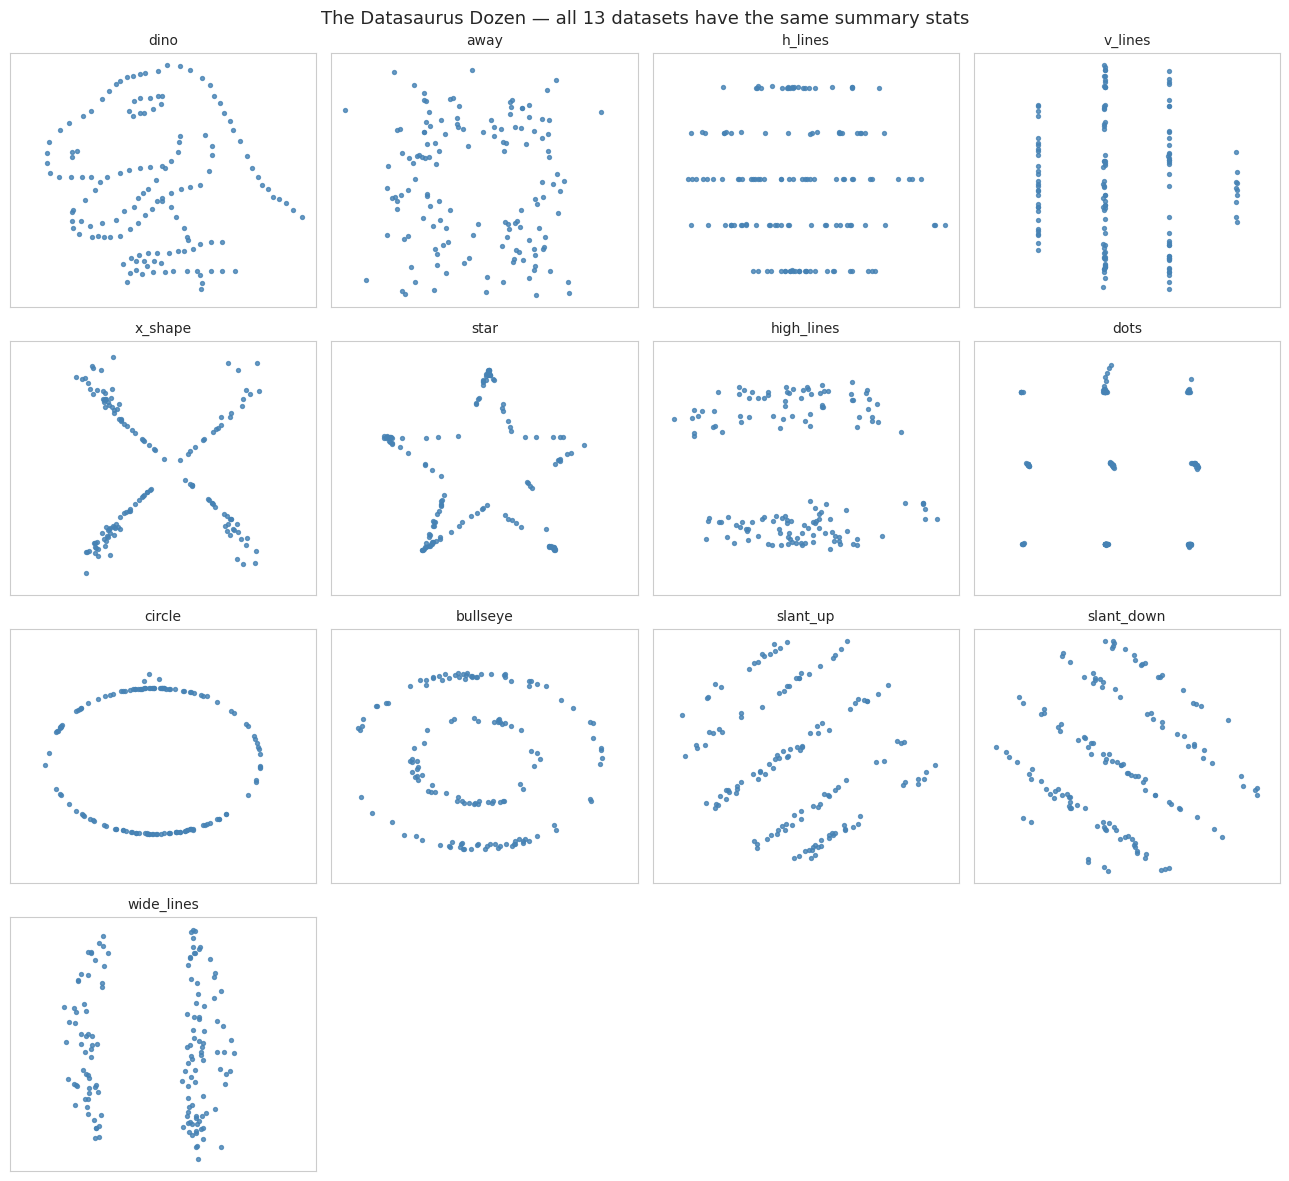

In [ ]:
# Plot all 13 datasets in a grid. Same means, same variances, same correlation.
# Nothing alike.
datasets = datasaurus['dataset'].unique()
n_cols = 4
n_rows = int(np.ceil(len(datasets) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3 * n_rows),
                          sharex=True, sharey=True)
for ax, name in zip(axes.flat, datasets):
    subset = datasaurus[datasaurus['dataset'] == name]
    ax.scatter(subset['x'], subset['y'], s=8, color='steelblue', alpha=0.8)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide any unused subplots
for ax in axes.flat[len(datasets):]:
    ax.axis('off')

fig.suptitle('The Datasaurus Dozen — all 13 datasets have the same summary stats',
             fontsize=13)
plt.tight_layout()
plt.show()

A dinosaur. A star. Concentric circles. A bullseye. Parallel lines. Stacked horizontal lines.

**Every single one of them has the same means, the same variances, and the same correlation.** If you were told nothing else, you would have no way to distinguish them from one another. You would have no way to know you were trying to fit a line through a dinosaur.

This is the whole point.

---

## Putting It All Together

Here is the vocabulary of this notebook:

| Concept | Meaning |
|---|---|
| **Scatterplot** | A 2D picture in which each observation becomes one dot positioned by its $(x, y)$ values. |
| **Bivariate** | Involving two variables at once — the world scatterplots live in. |
| **Anscombe's Quartet** | Four datasets with identical summary stats but dramatically different shapes. |
| **Datasaurus Dozen** | A modern, more dramatic version of Anscombe's Quartet — 13 datasets, same stats, wildly different shapes (including a dinosaur). |
| **Y-outlier** | A point whose $y$ breaks the trend. Hurts accuracy but doesn't usually destroy the overall fit. |
| **High-leverage point** | A point with an extreme $x$. Has disproportionate power to tilt the fitted line. |

And the rule that ties them together:

> **Plot your data. Always. Summary statistics are blind to shape; your eyes are not.**

### Where We're Going Next

We now know two things:

1. To shrink the error of our baseline model, we need a *second* variable that carries information about the first.
2. We can tell, *visually*, when two variables move together. Because their scatterplot slopes upward (or downward).

But we can't build a model out of intuitive eyeballing. We need a number that measures how much two variables move together. That number is called **covariance**, and from it we'll build **correlation**.

[That's the next notebook -->](https://github.com/bsheese/cs377/blob/main/17_regression_crossval/17_0_Preliminaries/17_0_3_Covariance.ipynb)